# LightGBM SHAP for predicting use of thrombolysis

This model use 10 features:

* stroke_team_id
* stroke_severity
* prior_disability
* age
* infarction
* onset_to_arrival_time
* precise_onset_known
* onset_during_sleep
* arrival_to_scan_time
* afib_anticoagulant

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from dataclasses import dataclass
from lightgbm import LGBMClassifier

/home/anna/miniconda3/envs/sam10/lib/python3.10/site-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/home/anna/miniconda3/envs/sam10/lib/python3.10/site-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimizat

## Set up paths and filenames

In [2]:
@dataclass(frozen=True)
class Paths:
    '''Singleton object for storing paths to data and database.'''

    data_read_path: str = './data/'
    output_folder = './output/'
    model_folder = './models'
    model_text = 'lgbm_decision_'
    notebook: str = '02_'

paths = Paths()

## Load data

In [4]:
# Load data
train = pd.read_csv(paths.data_read_path + 'cohort_10000_train.csv')
train['stroke_team_id'] = train['stroke_team_id'].astype('category')
test = pd.read_csv(paths.data_read_path + 'cohort_10000_test.csv')
test['stroke_team_id'] = test['stroke_team_id'].astype('category')

In [5]:
try:
    # Limit by year
    low_year = 2016
    high_year = 2018
    mask = (train['year'] >= low_year) & (train['year'] <= high_year)
    train = train[mask]
    train.drop('year', inplace=True, axis=1)
    mask = (test['year'] >= low_year) & (test['year'] <= high_year)
    test = test[mask]
    test.drop('year', inplace=True, axis=1)
except KeyError:
    # "year" isn't in the input data.
    pass

In [6]:
# Split X and y
X_train = train.drop('thrombolysis', axis=1)
X_test = test.drop('thrombolysis', axis=1)
y_train = train['thrombolysis']
y_test = test['thrombolysis']

# Get features
features = list(X_train)

In [7]:
features

['stroke_team_id',
 'stroke_severity',
 'prior_disability',
 'age',
 'infarction',
 'onset_to_arrival_time',
 'precise_onset_known',
 'onset_during_sleep',
 'arrival_to_scan_time',
 'afib_anticoagulant']

## Fit model

In [8]:
# Define model
model = LGBMClassifier(random_state=42, learning_rate=0.3)

# Fit model
model.fit(X_train, y_train)

# Get predictions
predicted = model.predict(X_test)
predicted_proba = model.predict_proba(X_test)[:,1]

# Show overall accuracy
accuracy = np.mean(predicted == y_test)
print (f'Accuracy: {accuracy:.3f}')

[LightGBM] [Info] Number of positive: 37150, number of negative: 90071
[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 686
[LightGBM] [Info] Number of data points in the train set: 127221, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.292012 -> initscore=-0.885634
[LightGBM] [Info] Start training from score -0.885634
Accuracy: 0.853


## Fit SHAP

In [9]:
explainer = shap.TreeExplainer(model)
shap_values_extended = explainer(X_test)
shap_values = explainer.shap_values(X_test)
shap_values_extended[0]

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


.values =
array([[-0.116704  ,  0.116704  ],
       [-2.21741366,  2.21741366],
       [ 2.94414052, -2.94414052],
       [ 0.11648366, -0.11648366],
       [-1.38909061,  1.38909061],
       [-3.000617  ,  3.000617  ],
       [-0.36164034,  0.36164034],
       [-0.11242719,  0.11242719],
       [-3.8841166 ,  3.8841166 ],
       [-0.28923313,  0.28923313]])

.base_values =
array([ 7.53873459, -7.53873459])

.data =
array([90. ,  8. ,  3. , 82.5,  1. , 83. ,  1. ,  0. , 20. ,  0. ])

In [158]:
shap_values_extended.feature_names

['stroke_team_id',
 'stroke_severity',
 'prior_disability',
 'age',
 'infarction',
 'onset_to_arrival_time',
 'precise_onset_known',
 'onset_during_sleep',
 'arrival_to_scan_time',
 'afib_anticoagulant']

## Show example waterfall plot

In [114]:
explainer.expected_value[class_index]

-7.538734592318922

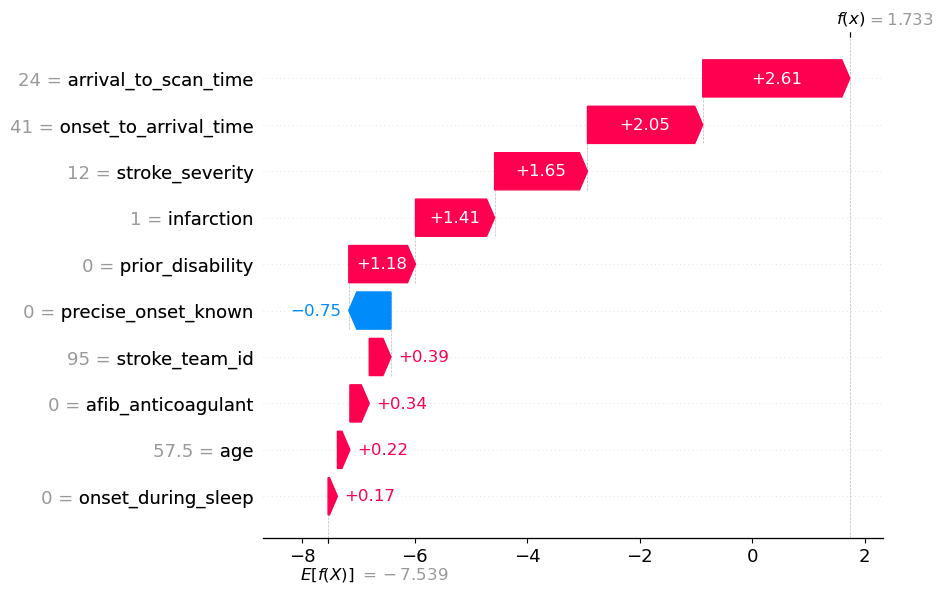

In [10]:
row = 5
class_index = 1

shap.waterfall_plot(shap.Explanation(
    values=shap_values[class_index][row],
    base_values=explainer.expected_value[class_index], data=X_test.iloc[row],
    feature_names=X_test.columns.tolist()))

## Beeswarm

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


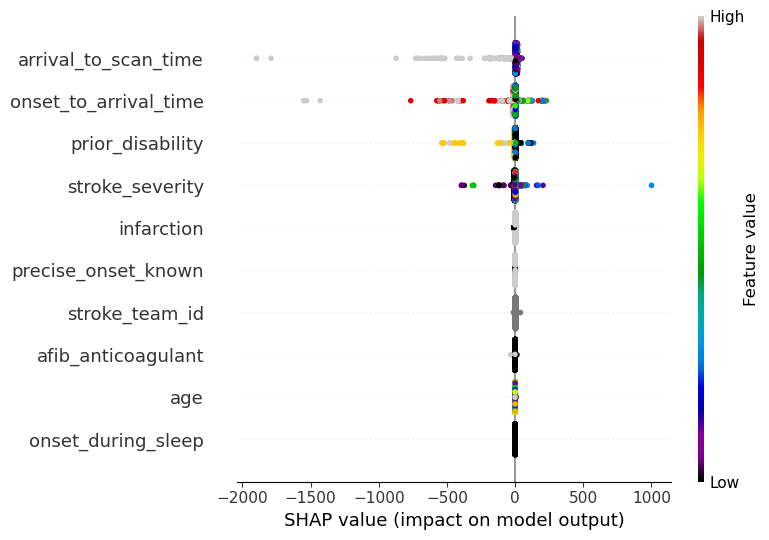

In [11]:
fig = plt.figure(figsize=(6,6))

shap.summary_plot(shap_values=shap_values[1], 
                  features=X_test,
                  feature_names=features,
                  max_display=10,
                  cmap=plt.get_cmap('nipy_spectral'), show=False)

filename = paths.output_folder + paths.notebook + paths.model_text + 'beeswarm.jpg'
plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()

## Get mean absolute SHAP values

In [12]:
mean_abs_shap = pd.Series(
    np.mean(np.abs(shap_values[1]), axis=0),
    index=features)
mean_abs_shap.sort_values(inplace=True, ascending=False)
mean_abs_shap.round(4)

arrival_to_scan_time     8.3419
onset_to_arrival_time    7.1116
prior_disability         3.5149
stroke_severity          2.6906
infarction               2.0428
precise_onset_known      0.5233
stroke_team_id           0.4858
afib_anticoagulant       0.4755
age                      0.1715
onset_during_sleep       0.1538
dtype: float64

## Get stroke team SHAP

In [46]:
features

['stroke_team_id',
 'stroke_severity',
 'prior_disability',
 'age',
 'infarction',
 'onset_to_arrival_time',
 'precise_onset_known',
 'onset_during_sleep',
 'arrival_to_scan_time',
 'afib_anticoagulant']

In [48]:
ind_stroke_team = features.index('stroke_team_id')

ind_stroke_team

0

In [56]:
# DataFrame of hopsital SHAP values for all patients
all_team_shap = pd.DataFrame()
all_team_shap['team_id'] = X_test['stroke_team_id']
all_team_shap['SHAP'] = hospital_shap_values = shap_values[1][:, ind_stroke_team]

# Get summary for teams
team_shap = pd.DataFrame()
team_shap['team_id'] = all_team_shap.groupby('team_id').groups.keys()
team_shap['SHAP_mean'] = all_team_shap.groupby('team_id').mean()
team_shap['SHAP_std'] = all_team_shap.groupby('team_id').std()

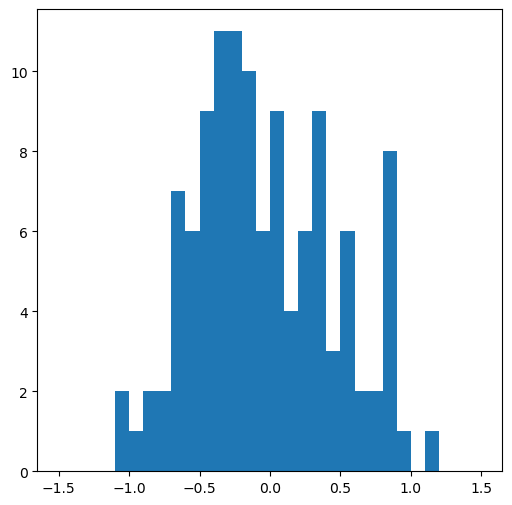

In [57]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot()
ax.hist(team_shap['SHAP_mean'], bins=np.arange(-1.5, 1.51, 0.1))

plt.show()

In [58]:
mean_shap = np.mean(team_shap['SHAP_mean'])
std_shap = np.std(team_shap['SHAP_mean'])
print(f'Mean hospital SHAP: {mean_shap:0.3f}')
print(f'Mean hospital SHAP STDdev: {std_shap:0.3f}')

Mean hospital SHAP: -0.039
Mean hospital SHAP STDdev: 0.490


## Extract benchmark ranking

In [59]:
shap_values[1].shape

(10000, 10)

In [60]:
shap_values[1][0]

array([ 0.24413887,  2.0318071 , -2.99349658, -0.0167298 ,  1.40099288,
        2.99391787,  0.60990611,  0.09322709,  3.87367585,  0.36411383])

In [66]:
team_shap = team_shap.sort_values('SHAP_mean', ascending=False)

team_shap

,team_id,SHAP_mean,SHAP_std
106,107,1.124348,0.398129
57,58,0.907725,0.283142
20,21,0.867138,1.629055
14,15,0.864108,0.302063
84,85,0.853830,1.634755
...,...,...,...
47,48,-0.873472,0.610930
16,17,-0.914772,0.335105
103,104,-1.052522,0.312441
114,115,-1.056769,0.579861


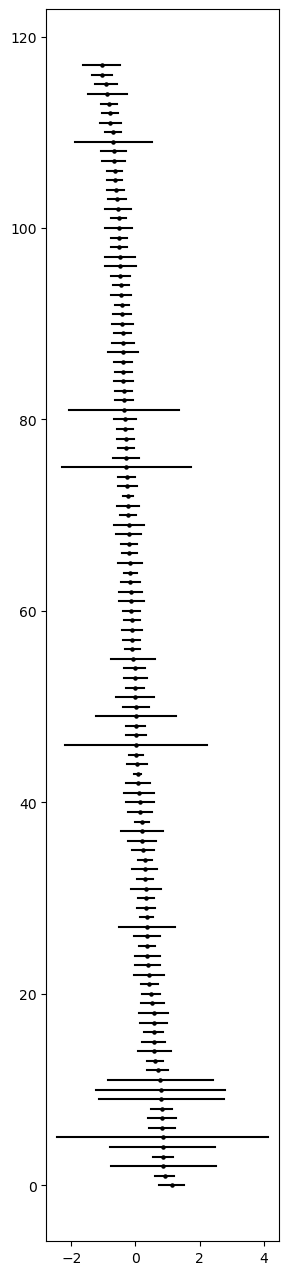

In [67]:
df = team_shap.copy()
# df = df.sort_values('SHAP_mean')

fig = plt.figure(figsize=(3, 16))

for i, ind in enumerate(df.index):
    team_mean = df.loc[ind]['SHAP_mean']
    team_std = df.loc[ind]['SHAP_std']
    plt.scatter(team_mean, i, color='k', s=5)
    plt.plot([team_mean-team_std, team_mean+team_std], [i, i], color='k')
plt.show()

In [35]:
features

['stroke_team_id',
 'stroke_severity',
 'prior_disability',
 'age',
 'infarction',
 'onset_to_arrival_time',
 'precise_onset_known',
 'onset_during_sleep',
 'arrival_to_scan_time',
 'afib_anticoagulant']

In [68]:
# Top 25 benchmark teams:
team_shap[:25]

,team_id,SHAP_mean,SHAP_std
106,107,1.124348,0.398129
57,58,0.907725,0.283142
20,21,0.867138,1.629055
14,15,0.864108,0.302063
84,85,0.853830,1.634755
93,94,0.846185,3.295790
4,5,0.824128,0.412340
53,54,0.824071,0.442610
108,109,0.814774,0.327372
113,114,0.800848,1.945864


In [94]:
benchmark_team_id_list = team_shap[:25].index.values

benchmark_team_id_list

array([106,  57,  20,  14,  84,  93,   4,  53, 108, 113,  62, 107,  74,
        48,  66,  45,  63,  82,  86,  34,  94,  81,  92,  89, 104])

## Benchmark scenario

In [87]:
# Make new data


In [151]:
filename = paths.data_read_path + 'reformatted_data_thrombolysis_decision.csv'
big_data = pd.read_csv(filename)

In [155]:
# Put data into the format for model
features_to_use = [
    'stroke_team_id',
    'stroke_severity',
    'prior_disability',
    'age',
    'infarction',
    'onset_to_arrival_time',
    'precise_onset_known',
    'onset_during_sleep',
    'arrival_to_scan_time',
    'afib_anticoagulant',
    # 'year',    
    'thrombolysis'
]

big_data = big_data[features_to_use]


In [156]:
def predict_benchmark_thrombolysis(
        model,
        team_big_df_orig,
        benchmark_team_id_list,
        stroke_team_id_column='stroke_team_id',
        prediction_column='thrombolysis'
        ):
    """
    Predict thrombolysis rate according to benchmark teams.
    
    model - trained model for predicto
    team_big_df - all data for the hospital we're testing
    benchmark_team_id_list - what we change the stroke team id to for the benchmark teams
    """
    # Sanity checks
    # Does the input dataframe contain the named columns for
    # stroke team ID and predicted quantity?
    # And does it contain all of the features that are expected
    # by the model?
    data_columns = list(team_big_df_orig.columns)
    feature_names = model.feature_name_
    err_str = ''
    err_count = 1
    if stroke_team_id_column not in data_columns:
        err_str += ''.join([
            f'Problem {err_count}: ',
            f'Expected a column named {stroke_team_id_column} ',
            'to contain the stroke team IDs. ',
            'You can set the expected column name with the kwarg ',
            '"stroke_team_id_column".\n'
            ])
        err_count += 1
    else:
        pass
    
    # Check that all expected feature names are present in the data.
    # The order of the features doesn't matter, just that they
    # exist.
    for feature in feature_names:
        if feature not in data_columns:
            err_str += ''.join([
                f'Problem {err_count}: ',
                f'Expected a column named {feature}.\n'
                ])
            err_count += 1
        else:
            pass
            
    # Print a warning message if necessary:
    if len(err_str) > 0:
        raise KeyError(err_str)
    else:
        pass

    
    # Store results for all benchmark teams in here:
    all_benchmark_predictions = pd.DataFrame()
    
    for benchmark_team_id in benchmark_team_id_list:
        # Make a copy of the original hospital data
        team_big_df = team_big_df_orig.copy()
        # Update the stroke team ID to match the benchmark hospital ID:
        team_big_df[stroke_team_id_column] = benchmark_team_id
        # This conversion must go after the hospital ID is updated:
        team_big_df[stroke_team_id_column] = team_big_df[
            stroke_team_id_column].astype('category')

        # Get predictions
        predicted = model.predict(team_big_df)

        # Store the results in the big results dataframe:
        all_benchmark_predictions[benchmark_team_id] = predicted

    # Find majority decision.    
    # How many teams must say "yes" for the majority to be "yes"?
    # e.g. for 25 teams, this value is 13.
    bench_majority_threshold = int(np.ceil(0.5 * len(benchmark_team_id_list)))
    # Add a column for the majority vote.
    all_benchmark_predictions['majority_vote'] = (
        all_benchmark_predictions.sum(axis=1)
        // bench_majority_threshold
        )
    # ^ the // means that when the number of teams answering "yes" is 
    # at least the majority threshold, the value is 1 and when the
    # number of teams is less than the threshold, the value is 0.
    return all_benchmark_predictions


In [157]:
for team_id in sorted(list(set(big_data['stroke_team_id']))):
    
    # Data for all patients at this hospital
    team_big_df_orig = big_data[big_data['stroke_team_id'] == team_id].copy()
    # Drop the thrombolysis result:
    team_big_df_orig = team_big_df_orig.drop('thrombolysis', axis=1).copy()
    # Now the input dataframe should have the same columns as the
    # data that was used to train the model.
    
    predictions_for_this_team = predict_benchmark_thrombolysis(
        model, 
        team_big_df_orig, 
        benchmark_team_id_list, 
        stroke_team_id_column='stroke_team_id'
        )

    print(team_id, f"Benchmark thrombolysis rate: {100*predictions_for_this_team['majority_vote'].mean():.1f}%")
    # print(stop, here, please)

1 Benchmark thrombolysis rate: 22.8%
2 Benchmark thrombolysis rate: 24.7%
3 Benchmark thrombolysis rate: 19.5%
4 Benchmark thrombolysis rate: 20.7%
5 Benchmark thrombolysis rate: 13.4%
6 Benchmark thrombolysis rate: 15.8%
7 Benchmark thrombolysis rate: 25.7%
8 Benchmark thrombolysis rate: 14.4%
9 Benchmark thrombolysis rate: 28.4%
10 Benchmark thrombolysis rate: 27.1%
11 Benchmark thrombolysis rate: 19.2%
12 Benchmark thrombolysis rate: 15.6%
13 Benchmark thrombolysis rate: 17.6%
14 Benchmark thrombolysis rate: 29.5%
15 Benchmark thrombolysis rate: 18.9%
16 Benchmark thrombolysis rate: 22.4%
17 Benchmark thrombolysis rate: 13.9%
18 Benchmark thrombolysis rate: 24.7%
19 Benchmark thrombolysis rate: 22.3%
20 Benchmark thrombolysis rate: 13.9%
21 Benchmark thrombolysis rate: 19.2%
22 Benchmark thrombolysis rate: 38.6%
23 Benchmark thrombolysis rate: 17.4%
24 Benchmark thrombolysis rate: 22.2%
25 Benchmark thrombolysis rate: 25.4%
26 Benchmark thrombolysis rate: 20.3%


KeyboardInterrupt: 